## 1.Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from warnings import filterwarnings
filterwarnings('ignore')

## 2.Load the Dataset

In [23]:
df = pd.read_csv('data/students_dropout_dataset.csv',sep=';')
y_target = 'Target'
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3.Dataset Overview

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [25]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [26]:
df.describe(include='object')

,Target
count,4424
unique,3
top,Graduate
freq,2209


## 4. Missing & Duplicate Values Analysis

In [27]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


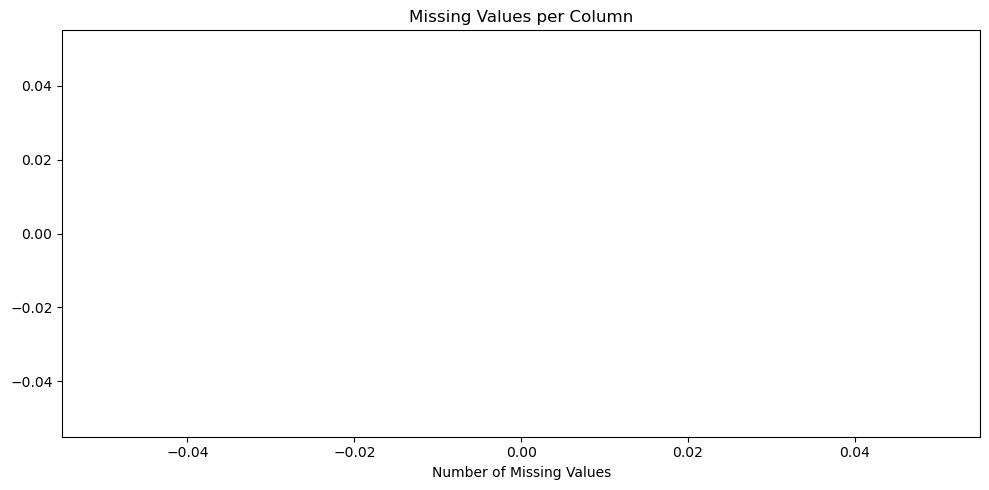

In [28]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage


## 5. Target Variabel Distribution

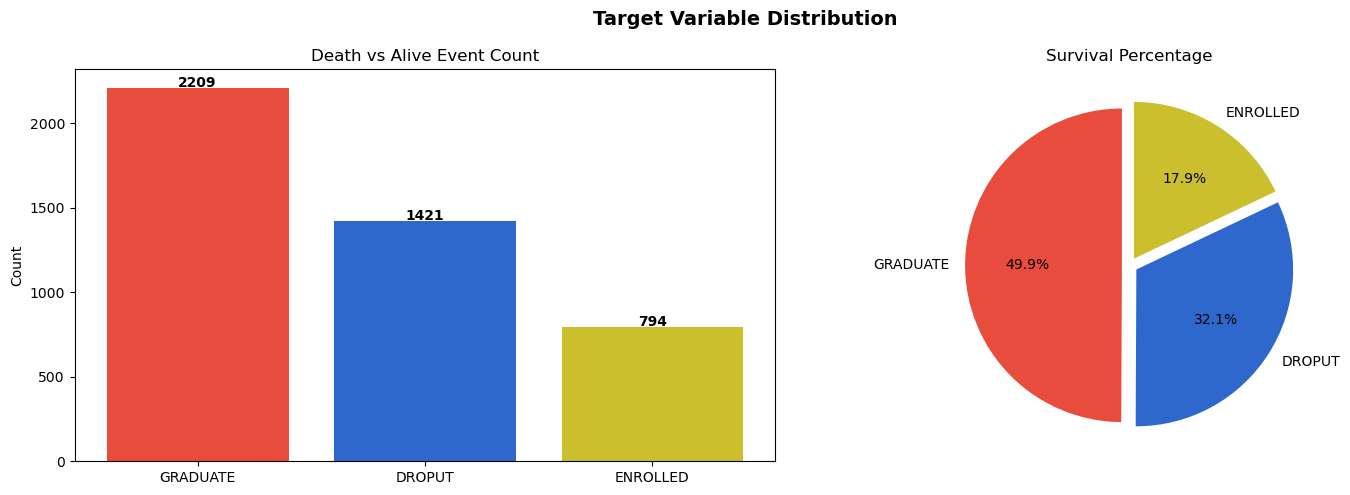

Graduate rate: 49.93%
Droput rate: 32.12%
enrolled rate: 17.95%


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
dropout_student = df[y_target].value_counts()

# Count plot
axes[0].bar(["GRADUATE","DROPUT","ENROLLED"], dropout_student.values,
            color=["#e74c3c", "#2e68cc", "#ccbf2e"])
axes[0].set_title("Death vs Alive Event Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(dropout_student.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(dropout_student.values, labels=["GRADUATE","DROPUT","ENROLLED"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2e68cc", "#ccbf2e"],
            startangle=90, explode=(0.05, 0.05,0.05))
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
graduate_rate = (len(df[df[y_target] == 'Graduate'] )/ len(df))
droput_rate = (len(df[df[y_target] == 'Dropout']) / len(df))
enrolled_rate = (len(df[df[y_target] == 'Enrolled']) / len(df))

print(f'Graduate rate: {graduate_rate:.2%}')
print(f'Droput rate: {droput_rate:.2%}')
print(f'enrolled rate: {enrolled_rate:.2%}')

In [31]:
df[y_target].describe(include='object')

count         4424
unique           3
top       Graduate
freq          2209
Name: Target, dtype: object

## 6. Univariate Analysis — Numerical Features

In [32]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (36):
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)']


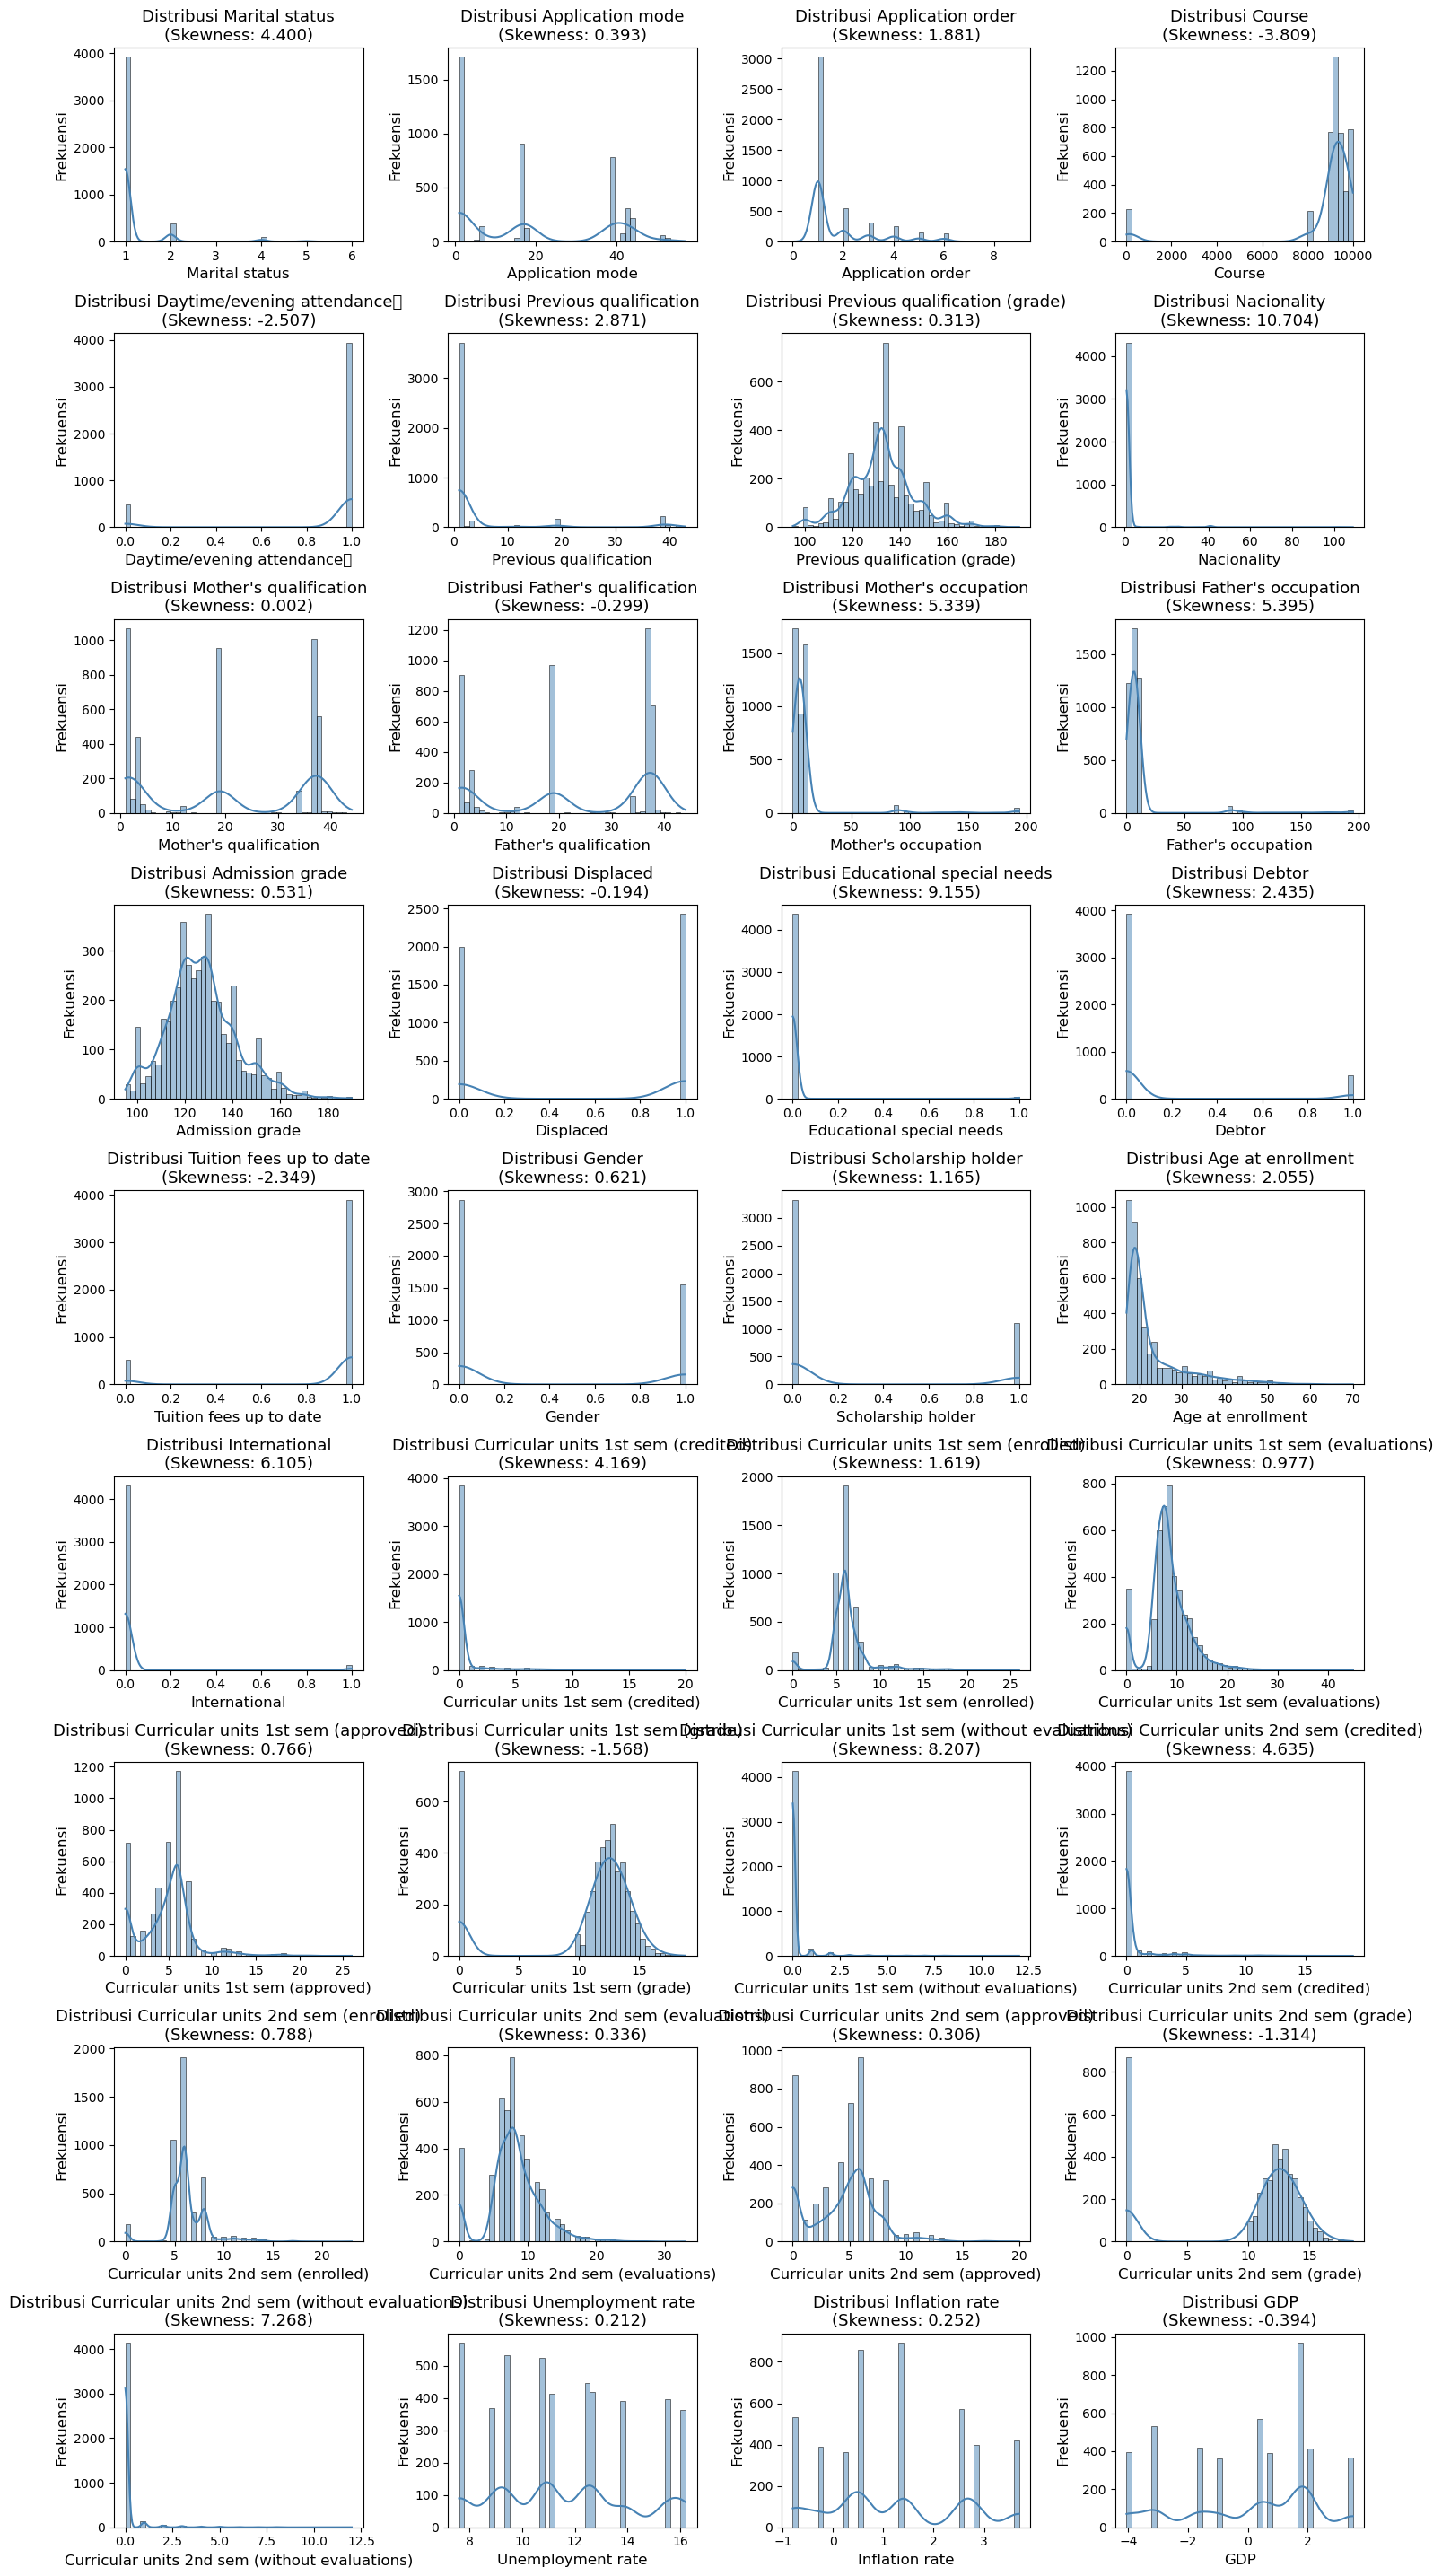

In [33]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

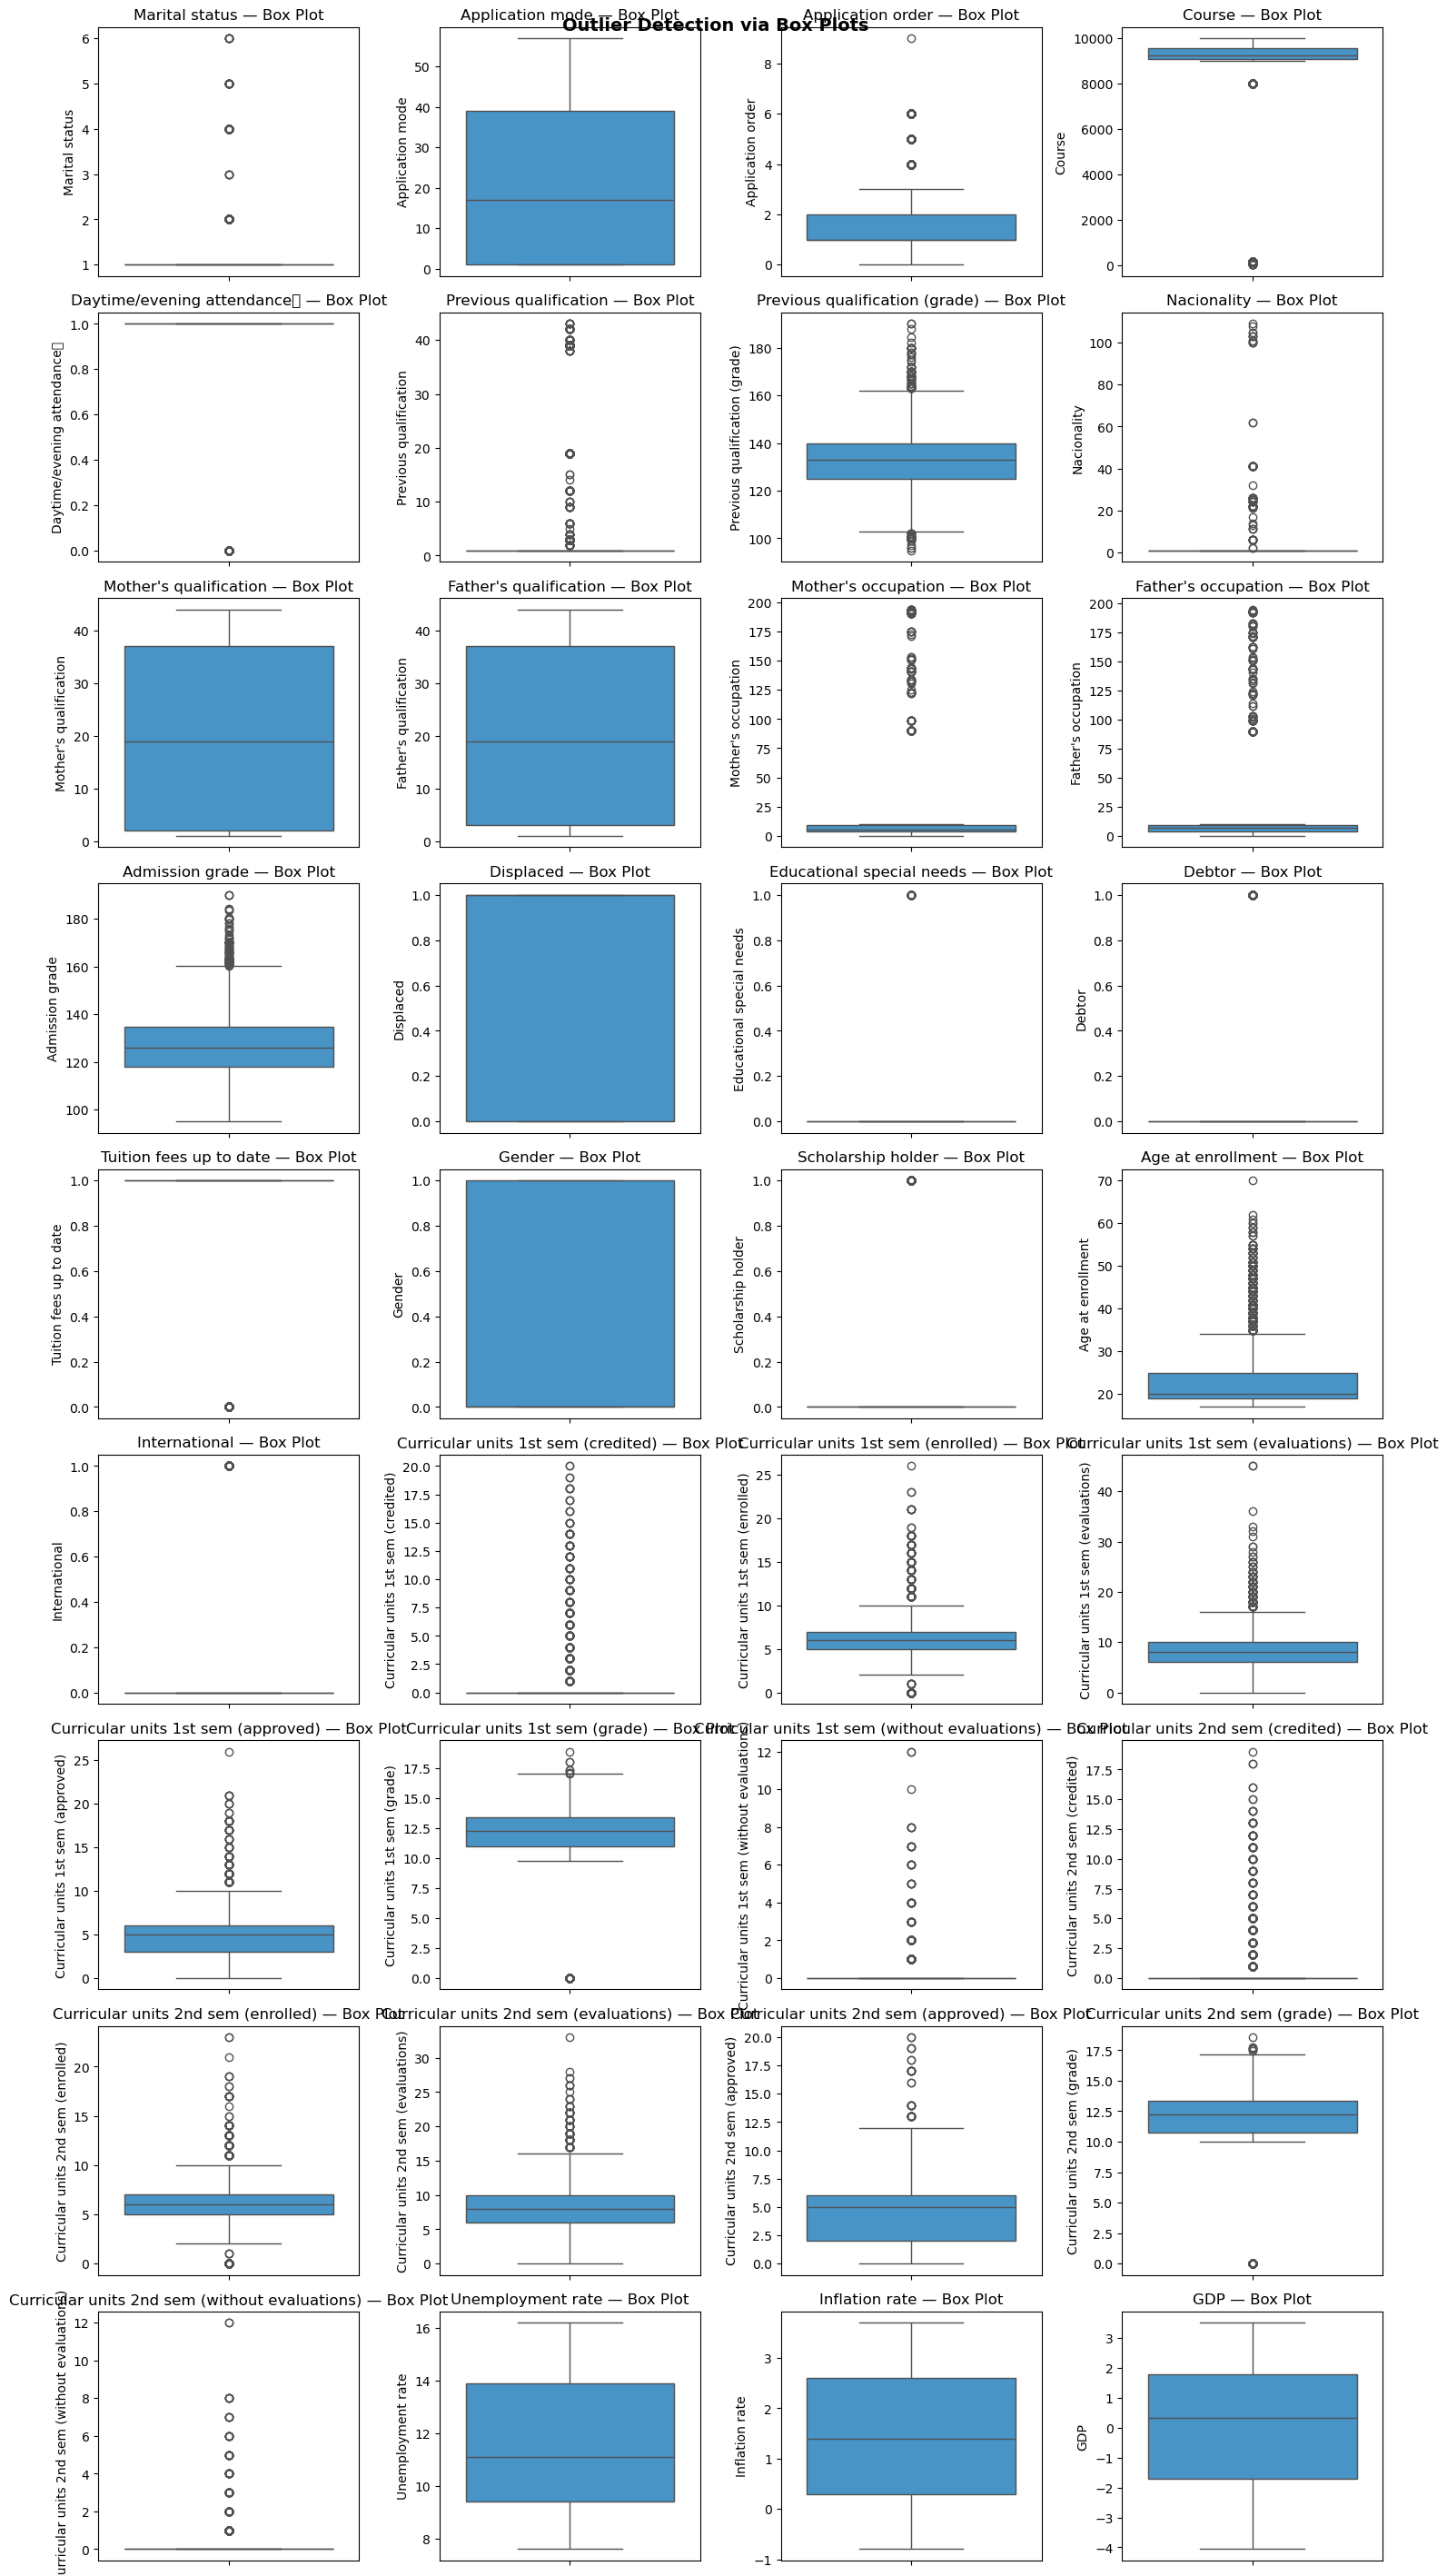

In [34]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features Numerik VS Target

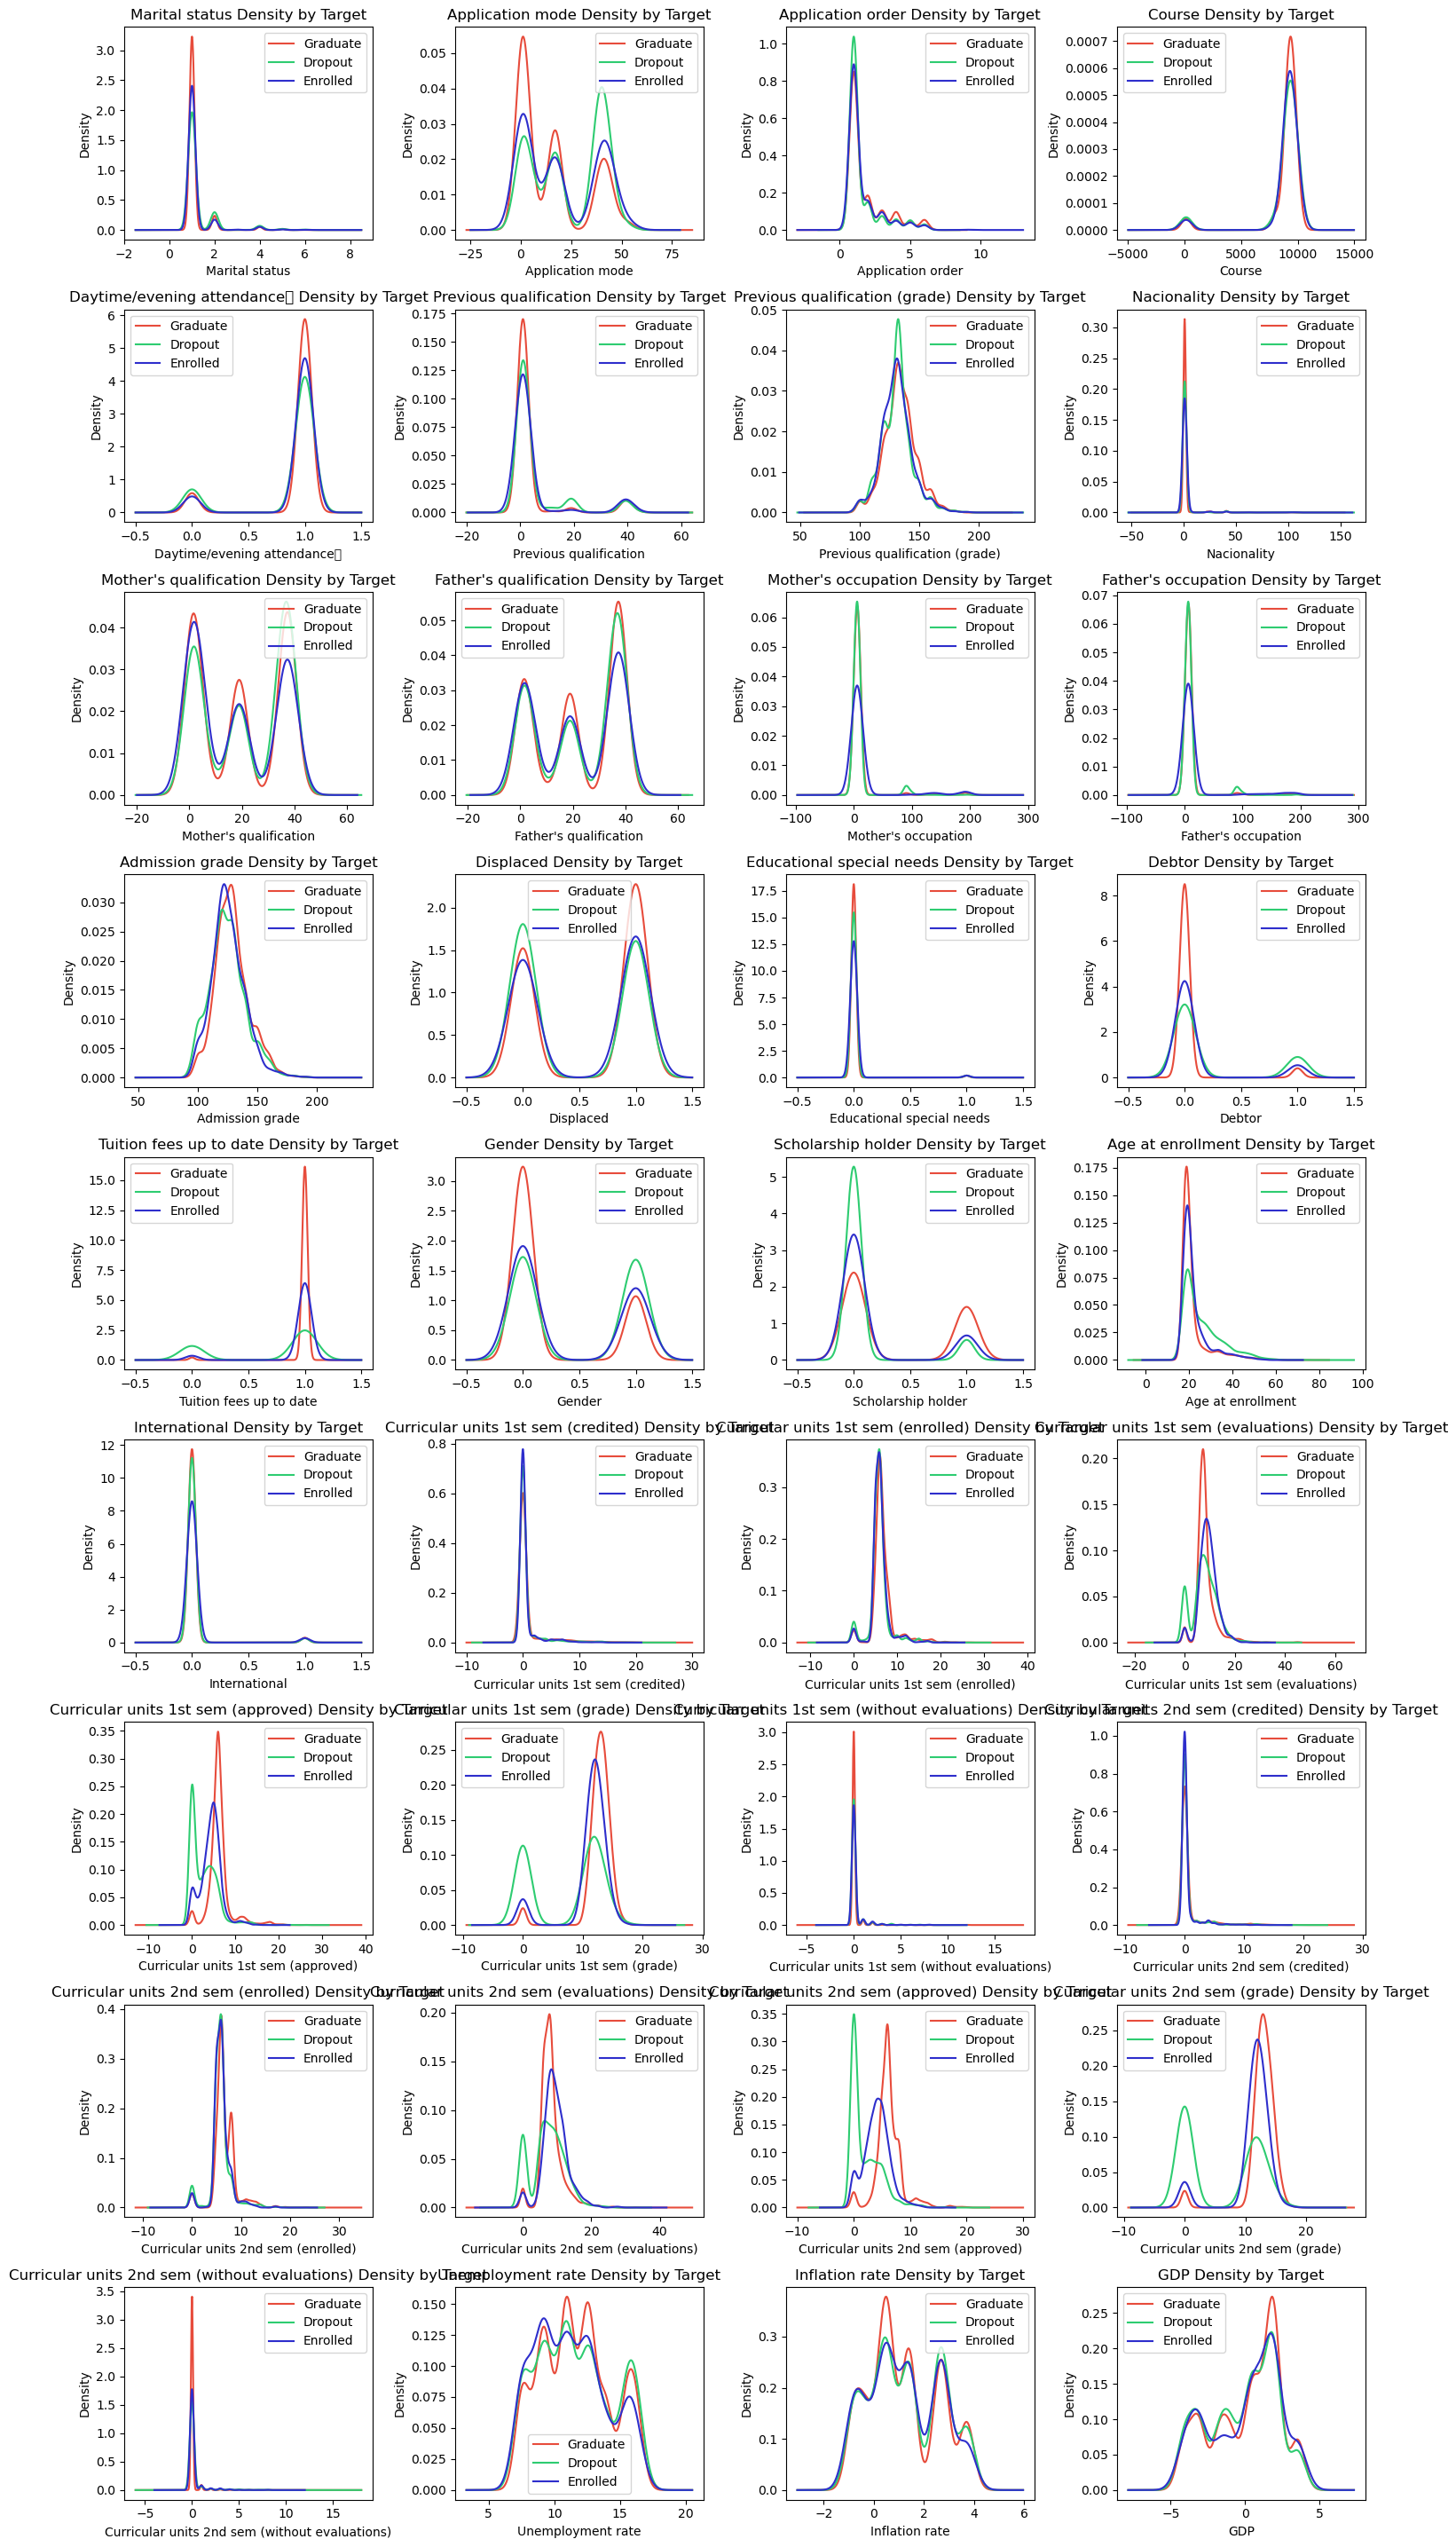

In [35]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,col in enumerate(feature_numerik):
    df[df[y_target] == 'Graduate'][col].dropna().plot.kde(ax=axes[i],color="#e74c3c",label='Graduate')
    df[df[y_target] == 'Dropout'][col].dropna().plot.kde(ax=axes[i],color="#2ecc71",label='Dropout')
    df[df[y_target] == 'Enrolled'][col].dropna().plot.kde(ax=axes[i],color="#2e2ecc",label='Enrolled')
    axes[i].set_title(f'{col} Density by {y_target}')
    axes[i].set_xlabel(f'{col}')
    axes[i].legend()
plt.tight_layout()
plt.show()

## 8. Multivariat Analysis

In [36]:
df_target = df.copy()

mapping_status = {'Graduate':0,'Dropout':1,'Enrolled':2}
df_target[y_target] = df_target[y_target].map(mapping_status)

feature_numerik = df_target.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df_target[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]

print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Curricular units 2nd sem (approved)               0.409
Curricular units 1st sem (approved)               0.354
Curricular units 2nd sem (grade)                  0.271
Curricular units 1st sem (grade)                  0.248
Scholarship holder                                0.244
Tuition fees up to date                           0.167
Gender                                            0.160
Application mode                                  0.153
Curricular units 2nd sem (enrolled)               0.150
Debtor                                            0.141
Curricular units 1st sem (enrolled)               0.135
Admission grade                                   0.106
Age at enrollment                                 0.100
Previous qualification (grade)                    0.098
Application order                                 0.080
Curricular units 2nd sem (without evaluations)    0.073
Curricular units 2nd sem (evaluations)            0.069
Displ

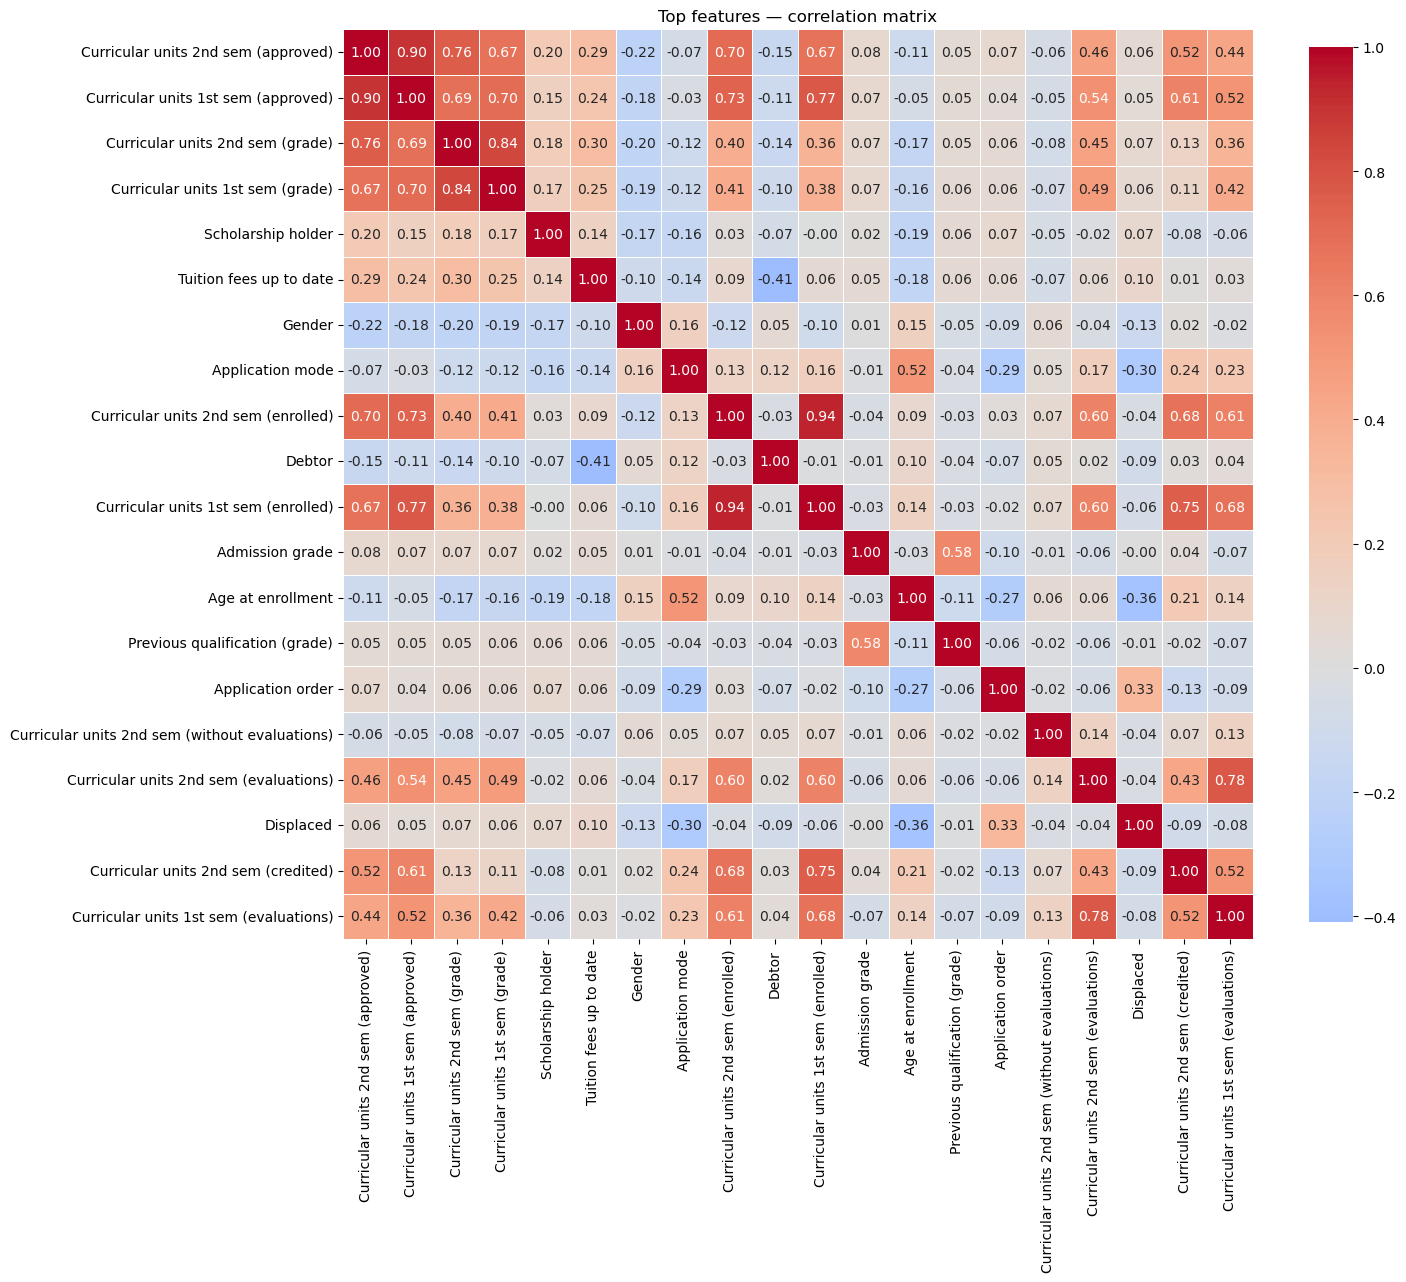

In [37]:
corr_matrix = df_target[top_features].corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

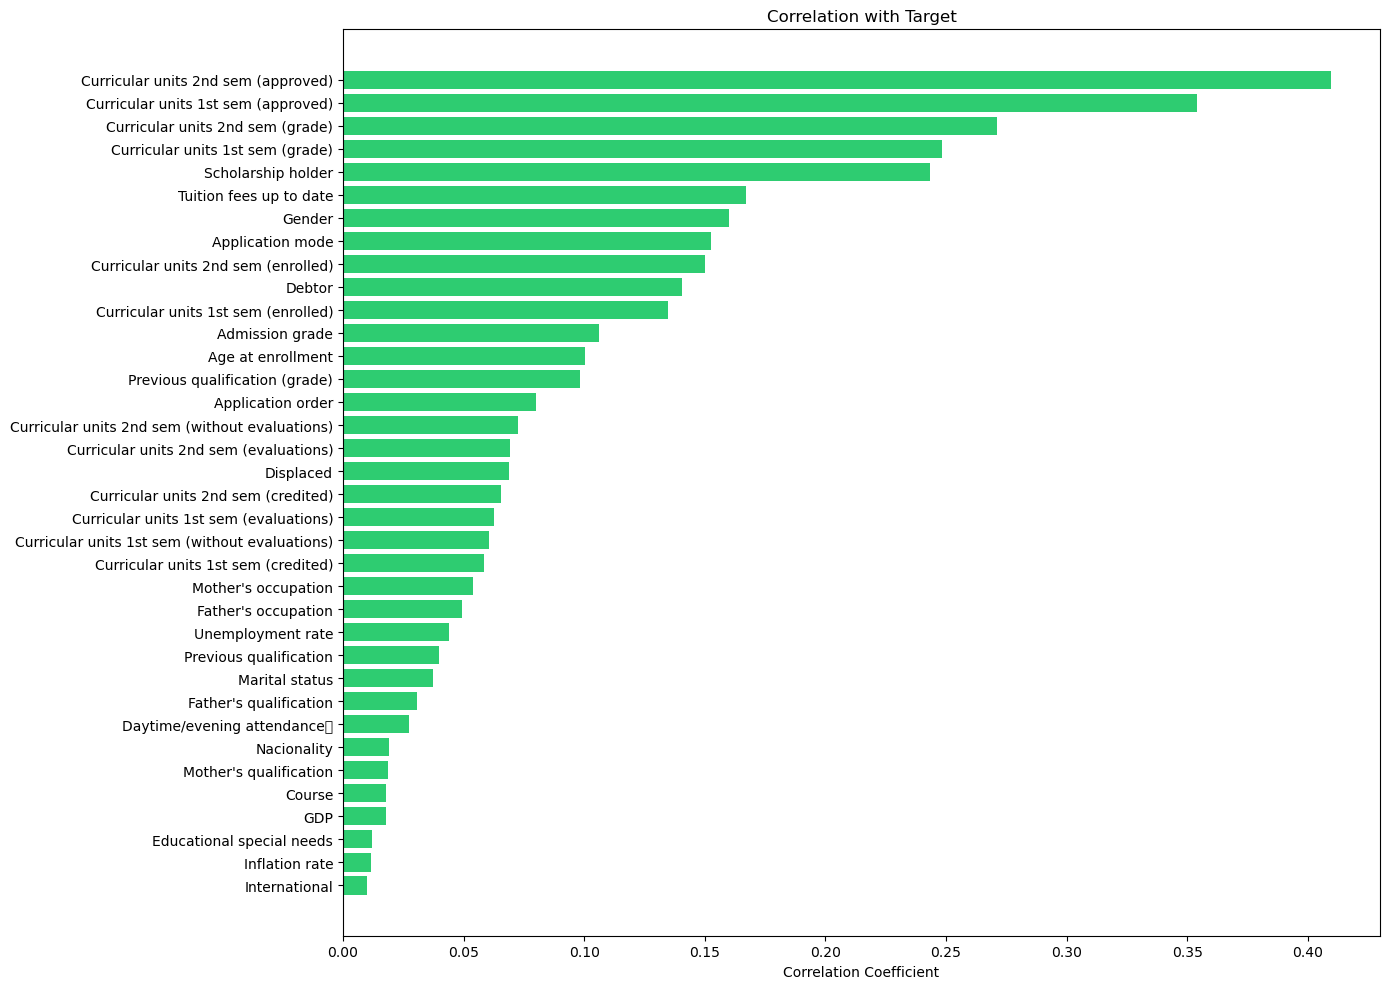

In [39]:
# Correlation with target
target_corr = df_target[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 9.Summary of EDA Findings

In [41]:
mapping_status = {'Graduate':0,'Dropout':1,'Enrolled':2}
df[y_target] = df[y_target].map(mapping_status)
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,4424
1,Total features,36
2,Target mean,0.68
3,Target median,1.0
4,Target stddev,0.76
5,Target min,0
6,Target max,2
7,Target skewness,0.608
8,Top correlated feature,Curricular units 2nd sem (approved)
9,Top correlation value,0.409
